## Descriptive Analysis

This notebook performs descriptive analysis of Canada's labour market using the final modeling dataset created in Sprint 2.

Dataset:

final_dataset.csv
Goal:

Understand historical trends
Explore job vacancies, unemployment, and labour market imbalance (θ)
Identify pre-COVID, COVID, and post-COVID patterns
No data cleaning is performed here.

## 1. Dataset Scope and Structural Integrity

This analysis uses a monthly Canadian labour market dataset covering the period from 2015 to 2024.

The dataset contains:

- National-level (Canada) labour force statistics
- Seasonally adjusted values
- Employment, Unemployment, Labour Force, Population
- Job Vacancies
- Labour Market Imbalance Indicator (θ = Vacancies / Unemployment)

The COVID-19 vacancy reporting suspension period (April–September 2020) has been structurally removed to avoid artificial distortion in the imbalance indicator.

The resulting dataset contains continuous monthly observations and no missing values, ensuring statistical consistency for descriptive evaluation.


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# DATASET VALIDATION AND STRUCTURAL CONFIRMATION
# ============================================================

import pandas as pd

# Load final cleaned dataset prepared in the data preparation phase
des_df = pd.read_csv("../1_data/processed/final_dataset.csv")

# Convert month column to datetime format for time-series handling
des_df["month"] = pd.to_datetime(des_df["month"])

# Sort chronologically to ensure proper time ordering
des_df = des_df.sort_values("month").reset_index(drop=True)

# ------------------------------------------------------------
# Structural Checks
# ------------------------------------------------------------

print("Number of observations:", len(des_df))
print("Date range:", des_df["month"].min(), "to", des_df["month"].max())
print("Number of variables:", len(des_df.columns))

print("\nMissing values per column:")
print(des_df.isna().sum())

print("\nDuplicate months:", des_df["month"].duplicated().sum())




Number of observations: 111
Date range: 2015-04-01 00:00:00 to 2024-12-01 00:00:00
Number of variables: 7

Missing values per column:
month           0
Employment      0
Unemployment    0
Labour force    0
Population      0
vacancies       0
theta           0
dtype: int64

Duplicate months: 0


In [3]:
des_df.info()
des_df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   month         111 non-null    datetime64[ns]
 1   Employment    111 non-null    float64       
 2   Unemployment  111 non-null    float64       
 3   Labour force  111 non-null    float64       
 4   Population    111 non-null    float64       
 5   vacancies     111 non-null    float64       
 6   theta         111 non-null    float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 6.2 KB


(111, 7)

## 2. Structural Summary Statistics

This section presents descriptive statistics for key labour market indicators to establish their structural magnitude and variability over the study period.

The objective is to understand:

- Average employment levels
- Typical unemployment magnitude
- Vacancy scale relative to labour supply
- Dispersion in the labour market imbalance indicator (θ)

These statistics provide a quantitative baseline before examining time-series dynamics.


In [6]:
# ============================================================
# SECTION 2 — SUMMARY STATISTICS (Proper Formatting)
# ============================================================

summary_stats = des_df[[
    "Employment",
    "Unemployment",
    "Labour force",
    "Population",
    "vacancies",
    "theta"
]].describe().T

# Format macro variables with comma separators
macro_vars = ["Employment", "Unemployment", "Labour force", "Population", "vacancies"]

for col in ["mean", "std", "min", "25%", "50%", "75%", "max"]:
    summary_stats.loc[macro_vars, col] = summary_stats.loc[macro_vars, col].map(lambda x: f"{x:,.0f}")

# Format theta separately with 3 decimals
for col in ["mean", "std", "min", "25%", "50%", "75%", "max"]:
    summary_stats.loc["theta", col] = f"{float(summary_stats.loc['theta', col]):.3f}"

summary_stats


C:\Users\Anurodh\AppData\Local\Temp\ipykernel_12720\731773618.py:18: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['19,099,462' '1,289,656' '20,389,122' '31,024,942' '591,756']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  summary_stats.loc[macro_vars, col] = summary_stats.loc[macro_vars, col].map(lambda x: f"{x:,.0f}")
C:\Users\Anurodh\AppData\Local\Temp\ipykernel_12720\731773618.py:18: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['937,844' '184,955' '914,362' '1,457,035' '186,221']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  summary_stats.loc[macro_vars, col] = summary_stats.loc[macro_vars, col].map(lambda x: f"{x:,.0f}")
C:\Users\Anurodh\AppData\Local\Temp\ipykernel_12720\731773618.py:18: FutureWarning: Setting an item of in

,count,mean,std,min,25%,50%,75%,max
Employment,111.0,"19,099,462","937,844","17,819,400","18,381,750","18,920,500","19,791,800","20,917,400"
Unemployment,111.0,"1,289,656","184,955","1,007,100","1,152,000","1,246,800","1,365,250","1,863,400"
Labour force,111.0,"20,389,122","914,362","19,156,600","19,657,700","20,282,200","20,863,900","22,422,800"
Population,111.0,"31,024,942","1,457,035","29,000,400","29,798,800","30,832,400","31,921,150","34,285,100"
vacancies,111.0,"591,756","186,221","340,915","440,520","543,600","677,945","988,430"
theta,111.0,0.474,0.187,0.241,0.329,0.437,0.538,0.977


### Interpretation of Structural Magnitudes

The Canadian labour market over the study period exhibits strong structural scale and moderate variability.

Employment averaged approximately 19.1 million persons, with a range from 17.8 million to 20.9 million, reflecting both the COVID-19 contraction and subsequent recovery. Labour force levels averaged 20.4 million, closely tracking employment, indicating a relatively stable participation environment.

Unemployment averaged 1.29 million individuals, with a maximum of 1.86 million during the pandemic shock. The dispersion in unemployment (standard deviation ≈ 185,000) highlights the magnitude of macroeconomic disruption during crisis periods.

Job vacancies averaged approximately 592,000, but ranged from 341,000 to nearly 988,000. The upper bound indicates substantial post-pandemic labour demand tightness.

The labour market imbalance indicator (θ) averaged 0.474, meaning that, on average, there were roughly 0.47 vacancies per unemployed person. The maximum value of 0.977 suggests that, during peak tightening, vacancies nearly matched unemployment levels, indicating a historically tight labour market regime.

The relatively wide interquartile range for θ (0.329 to 0.538) confirms meaningful structural variation over the study period.


## Historical Labour Market Trends

This section examines the evolution of core labour market indicators over time to identify long-term structural patterns and macroeconomic disruptions.

The analysis begins with employment, which reflects labour absorption capacity and overall economic activity.


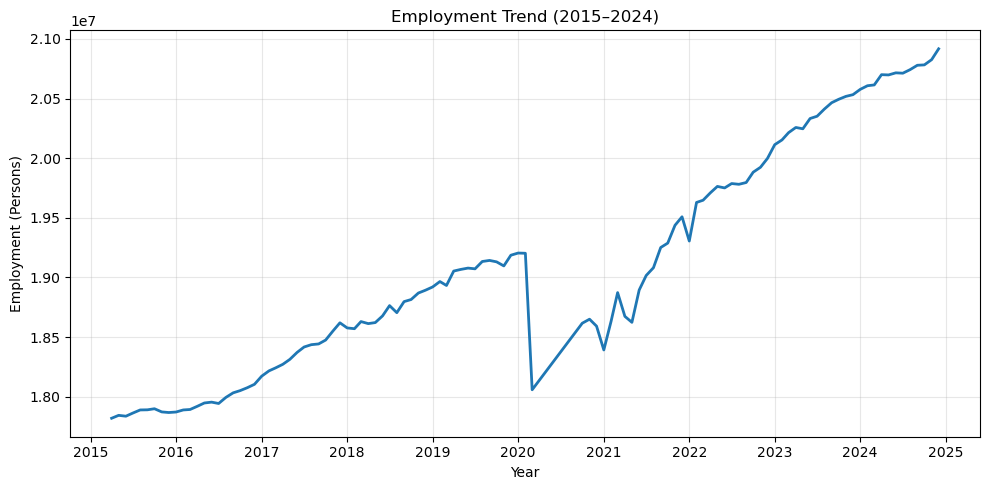

In [7]:
# ============================================================
# Employment Trend Over Time
# ============================================================

plt.figure(figsize=(10,5))

plt.plot(des_df["month"], des_df["Employment"], linewidth=2)

plt.title("Employment Trend (2015–2024)")
plt.xlabel("Year")
plt.ylabel("Employment (Persons)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


##  Unemployment Trend (2015–2024)

This section visualizes the historical evolution of unemployment in Canada from 2015 to 2024.

The goal is to:
- Identify long-term structural patterns
- Observe the COVID-19 disruption
- Examine the pace of recovery
- Compare stability before and after the shock

This is purely descriptive and does not involve modeling.


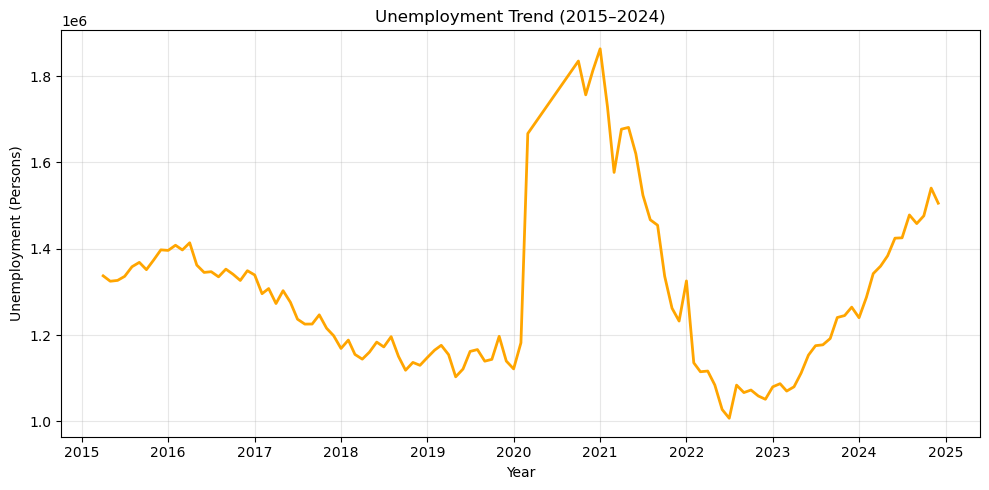

In [8]:
# ============================================================
# Unemployment Trend Over Time
# ============================================================

plt.figure(figsize=(10,5))

plt.plot(des_df["month"], des_df["Unemployment"], linewidth=2, color="orange")

plt.title("Unemployment Trend (2015–2024)")
plt.xlabel("Year")
plt.ylabel("Unemployment (Persons)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Job Vacancies Trend (Labour Demand)

This section visualizes total job vacancies in Canada over time.

Objective:
- Examine labour demand dynamics
- Identify pre-COVID baseline
- Observe COVID shock impact
- Analyze post-pandemic recovery pattern
- Compare visually with unemployment movement

This analysis remains purely descriptive.


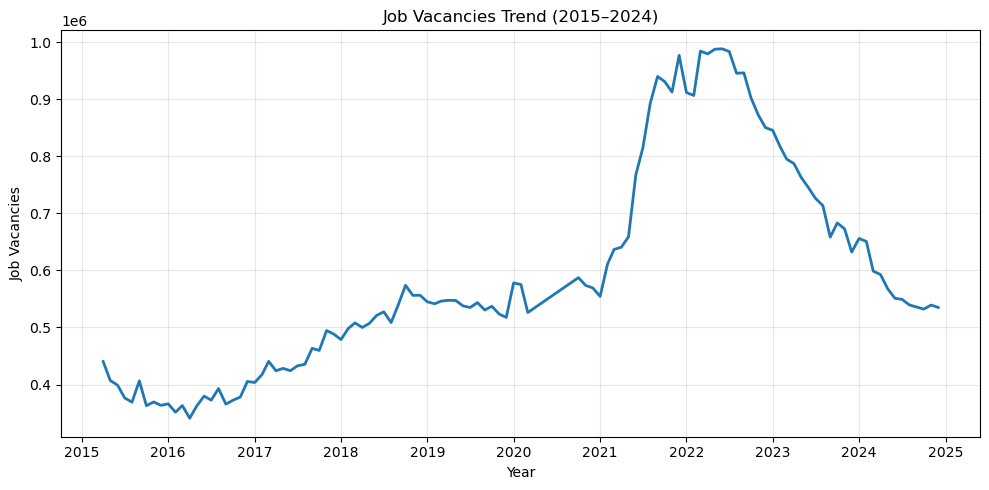

In [9]:
# ============================================================
# Job Vacancies Trend Over Time
# ============================================================

plt.figure(figsize=(10,5))

plt.plot(des_df["month"], des_df["vacancies"], linewidth=2)

plt.title("Job Vacancies Trend (2015–2024)")
plt.xlabel("Year")
plt.ylabel("Job Vacancies")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


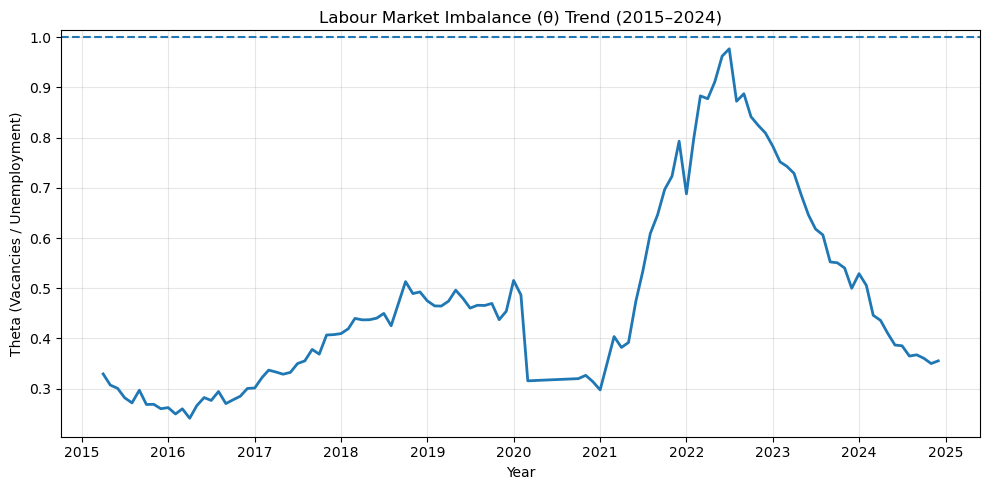

In [10]:
# ============================================================
# Labour Market Imbalance (Theta) Trend
# ============================================================

plt.figure(figsize=(10,5))

plt.plot(des_df["month"], des_df["theta"], linewidth=2)

plt.axhline(1, linestyle="--")  # Reference line for balance

plt.title("Labour Market Imbalance (θ) Trend (2015–2024)")
plt.xlabel("Year")
plt.ylabel("Theta (Vacancies / Unemployment)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Pre-COVID vs Post-COVID Descriptive Comparison

To better understand structural changes in Canada’s labour market, the dataset is divided into three periods:

1. Pre-COVID Period (2015–Feb 2020)
2. COVID Shock Period (Mar 2020–Sep 2020)
3. Post-COVID Recovery Period (Oct 2020 onward)

The objective is to compare average levels of:
- Employment
- Unemployment
- Job Vacancies
- Labour Market Imbalance (θ)

This allows identification of structural shifts in labour market tightness.


In [23]:
# Two-regime classification (gap months removed in preparation)
des_df["period"] = np.where(
    des_df["month"] < pd.Timestamp("2020-03-01"),
    "Pre-COVID",
    "Post-COVID"
)

# Optional: exclude the gap window if any rows still exist
gap_mask = (des_df["month"] >= "2020-04-01") & (des_df["month"] <= "2020-09-30")
des_df = des_df.loc[~gap_mask].copy()

period_summary = (
    des_df.groupby("period")[["Employment","Unemployment","vacancies","theta"]]
    .mean()
    .round(2)
)
period_summary


,Employment,Unemployment,vacancies,theta
period,,,,
Post-COVID,19833325.0,1335350.00,741201.73,0.59
Pre-COVID,18452667.8,1249383.05,460040.51,0.37


## Structural Shift in Labour Market Tightness

This bar chart compares the average labour market imbalance indicator (θ)
across three regimes:

- Pre-COVID
- Post-COVID

This visualization highlights structural changes in labour market tightness.


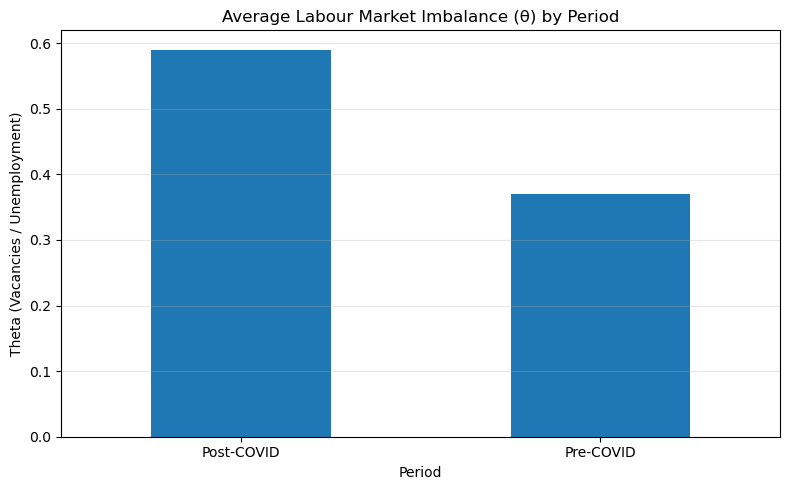

In [24]:
# ============================================================
# Bar Chart — Theta Across Periods
# ============================================================

plt.figure(figsize=(8,5))

period_summary["theta"].plot(kind="bar")

plt.title("Average Labour Market Imbalance (θ) by Period")
plt.ylabel("Theta (Vacancies / Unemployment)")
plt.xlabel("Period")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


### Interpretation of Structural Shift in Labour Market Tightness

The average labour market imbalance indicator (θ) increased from 0.37 in the pre-COVID period to 0.59 in the post-COVID period. This represents an approximate 60% increase in labour market tightness.

During the COVID shock period, θ declined to 0.32, reflecting a sharp increase in unemployment relative to job vacancies. However, in the post-pandemic recovery phase, job vacancies expanded significantly while unemployment normalized more gradually.

The elevated post-COVID θ suggests a structural shift in Canada’s labour market toward tighter conditions. This indicates stronger labour demand relative to available unemployed workers, which may reflect labour shortages, sectoral mismatches, or changes in workforce participation.

Overall, descriptive evidence suggests that the Canadian labour market transitioned from a relatively slack pre-pandemic environment to a substantially tighter post-pandemic regime.


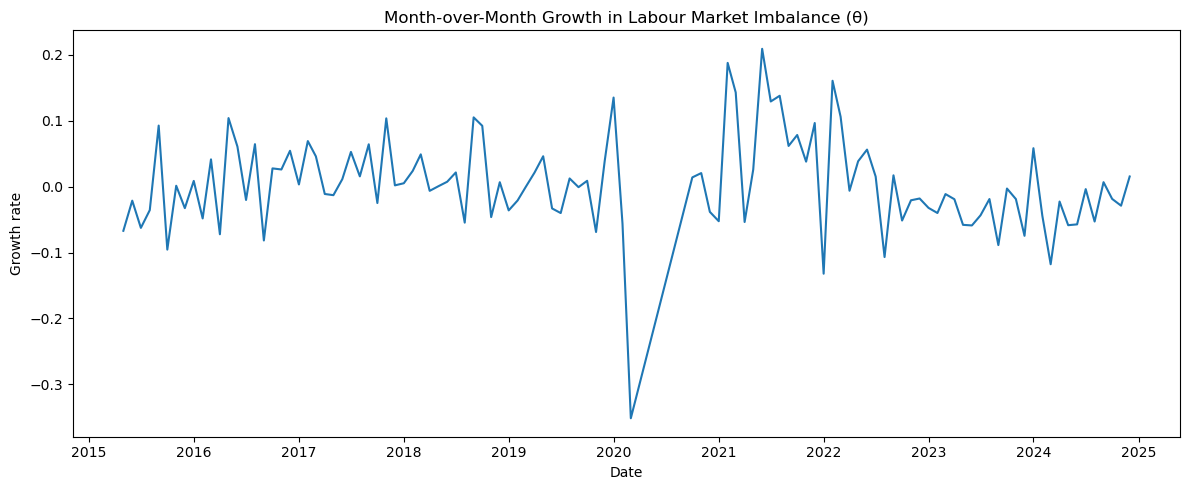

,month,theta,theta_growth
0,2015-04-01,0.329364,NaN
1,2015-05-01,0.307270,-0.067081
2,2015-06-01,0.300701,-0.021377
3,2015-07-01,0.281864,-0.062645
4,2015-08-01,0.271803,-0.035694
5,2015-09-01,0.296938,0.092475
6,2015-10-01,0.268557,-0.095578
7,2015-11-01,0.268891,0.001243


In [25]:
# =========================
# — Growth rate of θ (advanced descriptive) (run eighth)
# =========================
des_df["theta_growth"] = des_df["theta"].pct_change()

plt.figure(figsize=(12, 5))
plt.plot(des_df["month"], des_df["theta_growth"])
plt.title("Month-over-Month Growth in Labour Market Imbalance (θ)")
plt.xlabel("Date")
plt.ylabel("Growth rate")
plt.tight_layout()
plt.show()

# Quick check
display(des_df[["month", "theta", "theta_growth"]].head(8))

## Vacancy–Unemployment Relationship

This scatter plot examines the relationship between job vacancies and unemployment.

In a typical labour market:

- High unemployment → lower vacancies (slack market)
- Low unemployment → higher vacancies (tight market)

The visualization helps identify structural shifts in labour demand and labour supply.


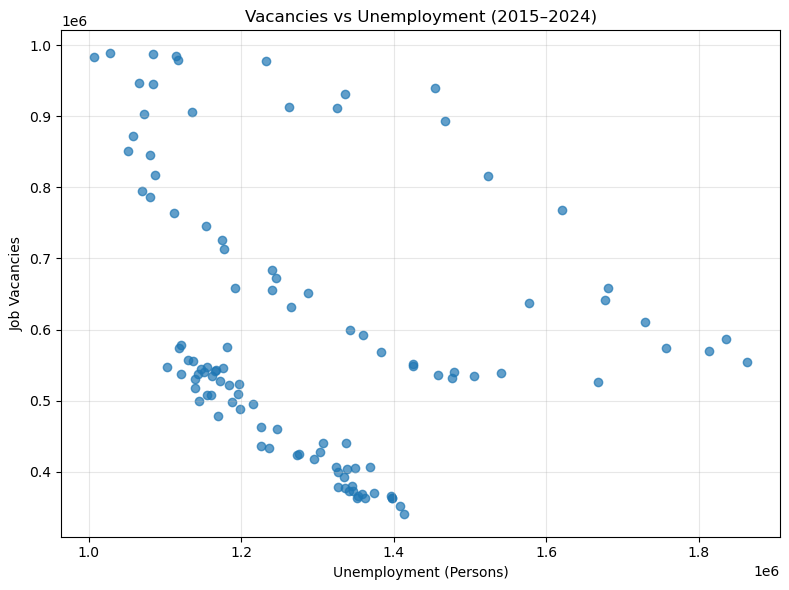

In [26]:
# ============================================================
# Vacancy vs Unemployment Scatter Plot
# ============================================================

plt.figure(figsize=(8,6))

plt.scatter(des_df["Unemployment"], des_df["vacancies"], alpha=0.7)

plt.title("Vacancies vs Unemployment (2015–2024)")
plt.xlabel("Unemployment (Persons)")
plt.ylabel("Job Vacancies")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Interpretation of Vacancy–Unemployment Relationship

The scatter plot reveals a clear inverse relationship between unemployment and job vacancies, consistent with standard labour market dynamics.

During the COVID shock period, unemployment increased sharply while vacancies declined or remained subdued. In contrast, the post-pandemic recovery period exhibits lower unemployment levels accompanied by substantially higher vacancy levels.

The clustering of post-COVID observations at higher vacancy levels for comparable unemployment levels suggests a structural shift in the labour market. This pattern resembles an outward movement of the Beveridge curve, potentially reflecting labour shortages, sectoral mismatches, or reduced labour market matching efficiency.

Overall, descriptive evidence indicates that Canada’s labour market has transitioned toward tighter post-pandemic conditions.


## Correlation Analysis

This section examines the correlation structure among:

- Employment
- Unemployment
- Job Vacancies
- Labour Market Imbalance (θ)

Correlation coefficients help quantify the strength and direction of relationships observed in the previous visualizations.


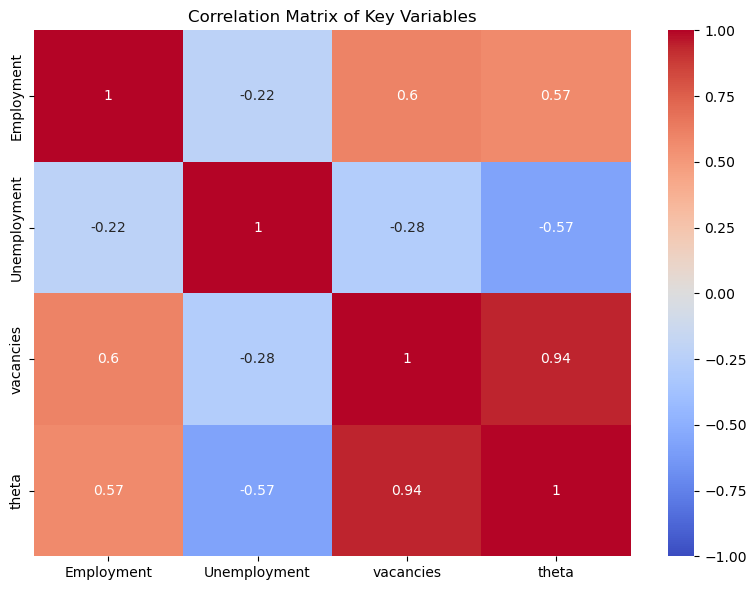

Correlation between Unemployment and Vacancies: -0.277
Correlation between Unemployment and Theta: -0.573


In [22]:
# ============================================================
# Correlation Matrix
# ============================================================

corr_matrix = des_df[[
    "Employment",
    "Unemployment",
    "vacancies",
    "theta"
]].corr().round(3)

corr_matrix
plt.figure(figsize=(8,6))  
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix of Key Variables")
plt.tight_layout()
plt.show()

print("Correlation between Unemployment and Vacancies:", corr_matrix.loc["Unemployment", "vacancies"])
print("Correlation between Unemployment and Theta:", corr_matrix.loc["Unemployment", "theta"])  

### Interpretation of Correlation Structure

The correlation matrix confirms expected labour market dynamics:

- Vacancies and unemployment exhibit a negative relationship (-0.28), consistent with standard labour demand theory.
- Employment and vacancies are positively correlated (0.60), reflecting increased labour demand during economic expansion.
- The labour market imbalance indicator (θ) shows a very strong positive correlation with vacancies (0.94) and a moderate negative correlation with unemployment (-0.57).

These results validate the internal consistency of the constructed indicator and support the descriptive evidence of post-pandemic labour market tightening.


,month_num,Employment,Unemployment,vacancies,theta
0,1,1.901491e+07,1.298022e+06,593305.555556,0.473475
1,2,1.909628e+07,1.275344e+06,596613.888889,0.483507
2,3,1.901166e+07,1.311922e+06,599929.444444,0.476967
3,4,1.900213e+07,1.283978e+06,583694.444444,0.471021
4,5,1.901389e+07,1.279311e+06,581153.888889,0.470612


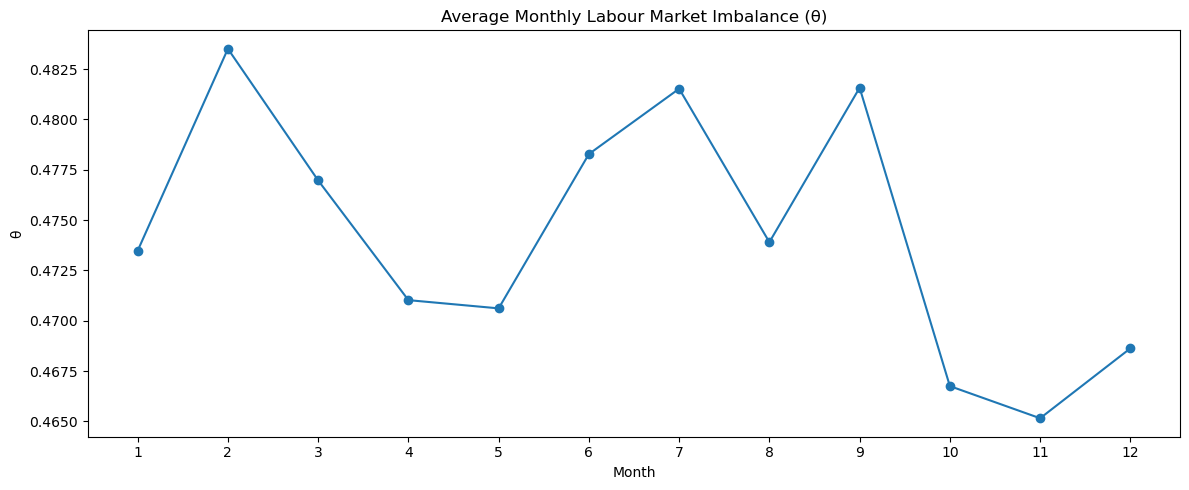

In [19]:
# =========================
# Seasonal descriptive patterns (month-of-year) (run eleventh)
# =========================
# ensure month_num exists (derived from the datetime month)
des_df["month_num"] = des_df["month"].dt.month

seasonal_summary = (
    des_df.groupby("month_num")[["Employment", "Unemployment", "vacancies", "theta"]]
    .mean()
    .reset_index()
)

display(seasonal_summary.head())

plt.figure(figsize=(12, 5))
plt.plot(seasonal_summary["month_num"], seasonal_summary["theta"], marker="o")
plt.title("Average Monthly Labour Market Imbalance (θ)")
plt.xlabel("Month")
plt.ylabel("θ")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

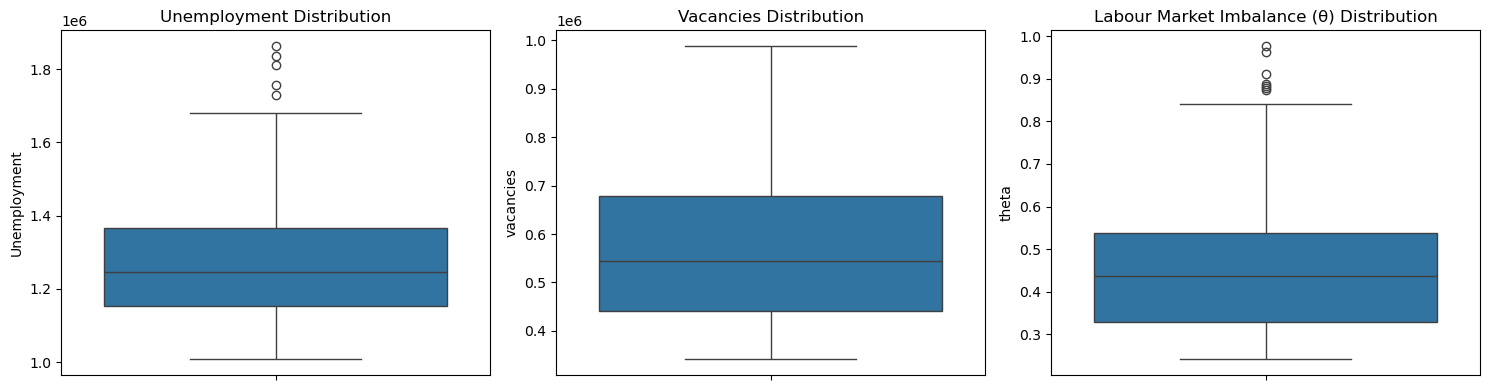

In [21]:
# =========================
# Distribution & tail behaviour (run thirteenth)
# =========================
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(y=  des_df["Unemployment"], ax=axs[0])
axs[0].set_title("Unemployment Distribution")

sns.boxplot(y=des_df["vacancies"], ax=axs[1])
axs[1].set_title("Vacancies Distribution")

sns.boxplot(y=des_df["theta"], ax=axs[2])
axs[2].set_title("Labour Market Imbalance (θ) Distribution")

plt.tight_layout()
plt.show()